In [1]:
import sys
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Subset
from torchvision.utils import make_grid
import torch.nn.functional as F


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random


import models as models
import train_helper as train_helper
import utils as utils
import data_helper as data_helper

vae_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST"
sys.path.append(vae_path)

In [4]:
# Set up device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_seed = 0
torch.manual_seed(base_seed)
torch.cuda.manual_seed_all(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)

model_saved_path = os.path.join(os.getcwd(),"model_saved")
data_saved_path = os.path.join(os.getcwd(),"data_saved")
results_saved_path = os.path.join(os.getcwd(),"results_saved")




# Prepare data


In [3]:


full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())

test_dataset = datasets.MNIST(root="./data", train=False, download=True,transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
full_digit_indices = utils.create_balanced_subset_indices(full_dataset,seed=base_seed)

#train_dataset_5000 = Subset(full_dataset, range(5000))


# Iterative training with prompt, to chose synthetic size

In [5]:
init_size = 500

test_results = {"val_loss":[], "val_recon":[], "val_kl":[], "model_name":[]}
init_subset = utils.get_balanced_subset(full_digit_indices, init_size)
init_dataset = Subset(full_dataset, init_subset)
init_loader = DataLoader(init_dataset, batch_size=128, shuffle=True)

valid_subset = utils.get_balanced_subset(full_digit_indices, [100,1100])
valid_dataset = Subset(full_dataset, valid_subset)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=True)

this_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20, name=f"cvae_conv_iclr_real_{init_size}",arch="conv").to(device)
train_helper.train_model(this_model, init_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)
val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
test_results["val_loss"].append(val_loss)
test_results["val_recon"].append(val_recon)
test_results["val_kl"].append(val_kl)
test_results["model_name"].append(this_model.get_name())
utils.save_model(this_model, this_model.name, model_saved_path)


Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_iclr_real_500.pth


In [6]:
test_results

{'val_loss': [121.07774626464844],
 'val_recon': [96.68207360839844],
 'val_kl': [24.395672555541992],
 'model_name': ['cvae_conv_iclr_real_500']}

In [7]:
size_schedule = [init_size]
all_models = [this_model]
max_syn_size = 2_000_000

for iter in range(15):
    val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, valid_loader, device)

    print(f"Iteration {iter} - Starting model: {this_model.get_name()}, Valid Loss: {val_loss:.4f} - Valid KL: {val_kl:.4f} - Valid Recon: {val_recon:.4f}")
    # Train Discriminator
    discriminator_dataset = data_helper.prepare_discriminator_dataset(full_dataset, this_model, device)
    disc_loader = DataLoader(discriminator_dataset, batch_size=128, shuffle=True)

    disc_model = models.SyntheticDiscriminator(input_dim=784)    
    train_helper.train_model(model=disc_model, train_loader=disc_loader, device=device, epochs=80, lr=1e-3, patience=5, verbose=False)

    candidate_models = []
    for factor in [1,1.5,2,4,8,16,32,64,128,256]:
        synthetic_size = (int(size_schedule[-1]*factor) // 10)*10

        if synthetic_size > max_syn_size:
            break

        synthetic_data_load_path = os.path.join(data_saved_path,this_model.get_name()+f'_q0.1_gen{synthetic_size}')
        # Generate Synthetic Data

        data_helper.generate_balanced_images_with_filtering(model=this_model, save_directory=synthetic_data_load_path, 
            total_samples=synthetic_size, discriminator=disc_model, selection_threshold=0.1, verbose=False, use_quantile_filtering=True)

        # Train Synthetic Model    
        synthetic_loader = data_helper.create_directory_based_dataloader(synthetic_data_load_path,batch_size=128)
        synthetic_model = models.CVAE(input_dim=784, label_dim=10,latent_dim=20, name=f"cvae_conv_iter{iter}_{synthetic_size}",arch="conv").to(device)
        train_helper.train_model(synthetic_model, synthetic_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)
        val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(synthetic_model, valid_loader, device)
        
        print(f"Iteration {iter} - Try Synthetic Size: {synthetic_size} - Val Loss: {val_loss:.4f} - Val KL: {val_kl:.4f} - Val Recon: {val_recon:.4f}")
        candidate_models.append([synthetic_size, synthetic_model, (val_loss,val_recon,val_kl)])

        del synthetic_loader

        ans = input("Continue increasing factor? [c]ontinue/[s]top: ").strip().lower()
        if ans.startswith("s"):
            break;
            
    for i, (size, model, loss) in enumerate(candidate_models):
        print(f"{i}: size={size}, model={model}, loss={loss}")
    print(flush=True)
    ans = input("which model to adopt? ").strip()
    this_size, this_model = candidate_models[int(ans)]
    utils.save_model(this_model, this_model.get_name(), model_saved_path)    
    size_schedule.append(this_size)
    all_models.append(this_model)
    val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
    test_results["val_loss"].append(val_loss)
    test_results["val_recon"].append(val_recon)
    test_results["val_kl"].append(val_kl)
    test_results["model_name"].append(this_mode.get_name())

    print(f"Iteration {iter} - Ending model: {this_model.get_name()}, Test Loss: {test_results['val_loss'][-1]:.4f} - Test KL: {test_results['val_kl'][-1]:.4f} - Test Recon: {test_results['val_recon'][-1]:.4f}")
    
    del disc_model
    del discriminator_dataset
    del disc_loader
    



Iteration 0 - Starting model: cvae_conv_real_500, Valid Loss: 123.6322 - Valid KL: 24.4554 - Valid Recon: 99.1768
Iteration 0 - Try Synthetic Size: 500 - Val Loss: 155.5867 - Val KL: 27.7433 - Val Recon: 127.8434


Continue increasing factor? [c]ontinue/[s]top:  c


Iteration 0 - Try Synthetic Size: 750 - Val Loss: 156.2350 - Val KL: 28.6668 - Val Recon: 127.5682


Continue increasing factor? [c]ontinue/[s]top:  c


Iteration 0 - Try Synthetic Size: 1000 - Val Loss: 156.2722 - Val KL: 28.6872 - Val Recon: 127.5849


...

Continue increasing factor? [c]ontinue/[s]top:  s


0: size=512000, model=CVAE(name=cvae_conv_iter14_512000, latent_dim=20)



which model to adopt?  0


Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_iter14_512000.pth
Iteration 14 - Ending model: cvae_conv_iter14_512000, Test Loss: 108.8507 - Test KL: 23.2177 - Test Recon: 85.6330


ValueError: All arrays must be of the same length

In [24]:
all_models_increase_size = all_models

In [20]:
res_table = pd.DataFrame.from_dict(test_results, orient='columns')
print(res_table)


      val_loss  val_recon     val_kl               model_name
0   121.077723  96.681870  24.395853       cvae_conv_real_500
1   114.339966  91.562635  22.777331    cvae_conv_iter0_32000
2   112.194556  89.396344  22.798213   cvae_conv_iter1_128000
3   110.643193  87.922448  22.720746   cvae_conv_iter2_256000
4   109.660475  86.911631  22.748844   cvae_conv_iter3_256000
5   109.359881  85.663940  23.695942   cvae_conv_iter4_512000
6   109.335023  85.399381  23.935642   cvae_conv_iter5_512000
7   108.849314  84.887011  23.962304   cvae_conv_iter6_512000
8   108.675768  85.001416  23.674352   cvae_conv_iter7_512000
9   108.826422  85.098014  23.728408   cvae_conv_iter8_512000
10  108.472341  84.693621  23.778720   cvae_conv_iter9_512000
11  108.802451  85.109068  23.693383  cvae_conv_iter10_512000
12  108.774207  84.990159  23.784047  cvae_conv_iter11_512000
13  108.750551  85.409855  23.340697  cvae_conv_iter12_512000
14  108.992824  85.362100  23.630725  cvae_conv_iter13_512000
15  108.

In [21]:
res_table.to_csv(os.path.join(results_saved_path, 'conv_q0.1_iter_choose_sizeschedule_results.csv'), index=False, mode='a', header=True)

## Check digit quality

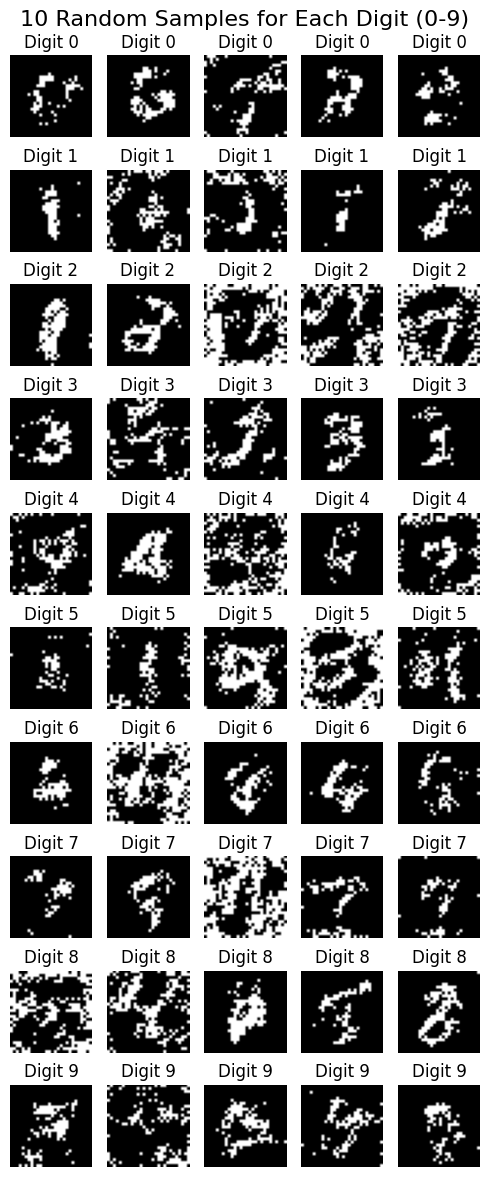

In [13]:
utils.plot_samples_per_digit(5,all_models[0])

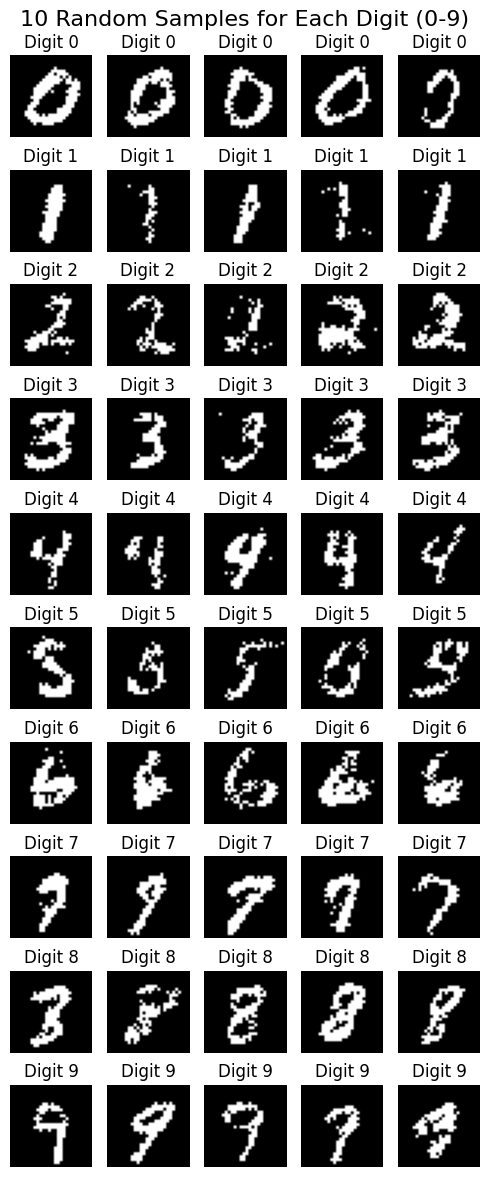

In [18]:
utils.plot_samples_per_digit(5,all_models[-1])

## Plot Loss function

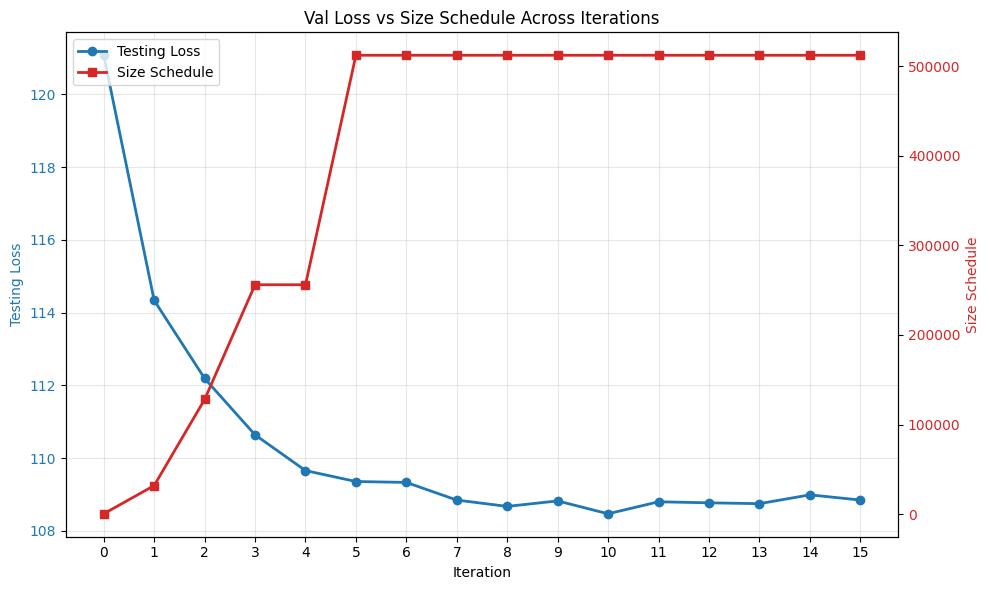

In [19]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot val_loss on primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Testing Loss', color=color)
line1 = ax1.plot(range(len(res_table['val_loss'])), res_table['val_loss'], 
                 color=color, marker='o', linewidth=2, markersize=6, label='Testing Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for size_schedule
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Size Schedule', color=color)
line2 = ax2.plot(range(len(size_schedule)), size_schedule, 
                 color=color, marker='s', linewidth=2, markersize=6, label='Size Schedule')
ax2.tick_params(axis='y', labelcolor=color)

# Add legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Set x-axis ticks to show iteration numbers
ax1.set_xticks(range(len(res_table['val_loss'])))
ax1.set_xticklabels(range(len(res_table['val_loss'])))

# Add title
plt.title('Val Loss vs Size Schedule Across Iterations')

# Adjust layout and show
plt.tight_layout()
plt.show()

# Iterative retraining with non-increasing schedule

In [33]:
init_size = 500

test_results = {"val_loss":[], "val_recon":[], "val_kl":[], "model_name":[]}

this_model = utils.load_model("cvae_conv_real_500", model_saved_path , device, (784, 10, 20, "cvae_conv_real_500","conv"))

val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
test_results["val_loss"].append(val_loss)
test_results["val_recon"].append(val_recon)
test_results["val_kl"].append(val_kl)
test_results["model_name"].append(this_model.get_name())



In [7]:
test_results

{'val_loss': [121.07774626464844],
 'val_recon': [96.68207360839844],
 'val_kl': [24.395672555541992],
 'model_name': ['cvae_conv_iclr_real_500']}

In [14]:
res_size_schedule = np.arange(1,20)*50000+30000

In [15]:
res_size_schedule

array([ 80000, 130000, 180000, 230000, 280000, 330000, 380000, 430000,
       480000, 530000, 580000, 630000, 680000, 730000, 780000, 830000,
       880000, 930000, 980000])

In [20]:

all_models = [this_model]

for i,synthetic_size in enumerate(size_schedule_fix):
    if i == 0:
        continue
    # Train Discriminator
    synthetic_size = int(synthetic_size)
    discriminator_dataset = data_helper.prepare_discriminator_dataset(full_dataset, this_model, device)
    disc_loader = DataLoader(discriminator_dataset, batch_size=128, shuffle=True)

    disc_model = models.SyntheticDiscriminator(input_dim=784)    
    train_helper.train_model(model=disc_model, train_loader=disc_loader, device=device, epochs=80, lr=1e-3, patience=5, verbose=False)

    # Generate Synthetic Data
    synthetic_data_load_path = os.path.join(data_saved_path,this_model.get_name()+f'_q0.1_gen{synthetic_size}')
    data_helper.generate_balanced_images_with_filtering(model=this_model, save_directory=synthetic_data_load_path,
        total_samples=synthetic_size, discriminator=disc_model, selection_threshold=0.1, verbose=False, use_quantile_filtering=True)

    # Train Synthetic Model    
    synthetic_loader = data_helper.create_directory_based_dataloader(synthetic_data_load_path,batch_size=128)
    synthetic_model = models.CVAE(input_dim=784, label_dim=10,latent_dim=20, name=f"cvae_conv_iclr_schedule_iter{i}_{synthetic_size}",arch="conv").to(device)
    train_helper.train_model(synthetic_model, synthetic_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)
    
    this_model = synthetic_model
    utils.save_model(this_model, this_model.get_name(), model_saved_path)
    all_models.append(this_model)
    
    val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
    test_results["val_loss"].append(val_loss)
    test_results["val_recon"].append(val_recon)
    test_results["val_kl"].append(val_kl)
    test_results["model_name"].append(this_model.get_name())

    
    print(f"Iteration {i} - Ending model: {this_model.get_name()}, Test Loss: {test_results['val_loss'][-1]:.4f} - Test KL: {test_results['val_kl'][-1]:.4f} - Test Recon: {test_results['val_recon'][-1]:.4f}")
    # utils.save_model(this_model, this_model.name, model_saved_path)

    del synthetic_loader
    del disc_model
    del discriminator_dataset
    del disc_loader
    

Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_iclr_schedule_iter1_30000.pth
Iteration 1 - Ending model: cvae_conv_iclr_schedule_iter1_30000, Test Loss: 114.7155 - Test KL: 22.8744 - Test Recon: 91.8411
Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_iclr_schedule_iter1_30000.pth
Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_iclr_schedule_iter2_80000.pth
Iteration 2 - Ending model: cvae_conv_iclr_schedule_iter2_80000, Test Loss: 112.6099 - Test KL: 23.2417 - Test Recon: 89.3682
Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_iclr_schedule_iter2_80000.pth
Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_conv_iclr_schedule_iter3_130000.pth
Iteration 3 - Ending model: cvae_conv_iclr_schedule_iter3_130000, Test Loss: 111.1573 - Test KL: 22.9133 - Test Recon: 88.2440
Model saved to /home/benjiy/repo/Verified-Syn

In [21]:
res_table_delta50K = pd.DataFrame.from_dict(test_results, orient='columns')
print(res_table_delta50K)

      val_loss  val_recon     val_kl                             model_name
0   121.077746  96.682074  24.395673                cvae_conv_iclr_real_500
1   114.715505  91.841147  22.874357    cvae_conv_iclr_schedule_iter1_30000
2   112.609874  89.368202  23.241671    cvae_conv_iclr_schedule_iter2_80000
3   111.157265  88.243992  22.913273   cvae_conv_iclr_schedule_iter3_130000
4   110.286491  87.146255  23.140236   cvae_conv_iclr_schedule_iter4_180000
5   110.013361  86.602614  23.410747   cvae_conv_iclr_schedule_iter5_230000
6   109.591574  85.768068  23.823506   cvae_conv_iclr_schedule_iter6_280000
7   109.724858  85.752410  23.972449   cvae_conv_iclr_schedule_iter7_330000
8   109.835932  85.634715  24.201217   cvae_conv_iclr_schedule_iter8_380000
9   110.128995  85.493349  24.635646   cvae_conv_iclr_schedule_iter9_430000
10  110.623277  85.934094  24.689183  cvae_conv_iclr_schedule_iter10_480000
11  110.846335  86.426484  24.419852  cvae_conv_iclr_schedule_iter11_530000
12  110.8340

In [22]:
res_table_delta50K.to_csv(os.path.join(results_saved_path, 'conv_q0.1_iter_retrain_delta50K_results.csv'), index=False, mode='a', header=True)

## Plot results

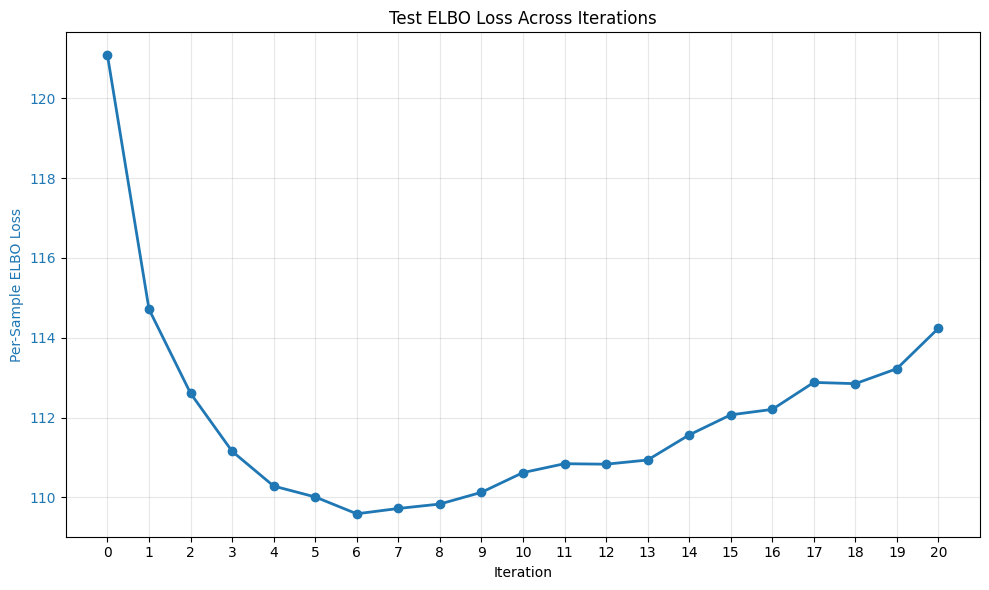

In [ ]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot val_loss on primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Per-Sample ELBO Loss', color=color)
line1 = ax1.plot(range(len(res_table_delta50K['val_loss'])), res_table_delta50K['val_loss'], 
                 color=color, marker='o', linewidth=2, markersize=6, label='Testing Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax1.set_xticks(range(len(res_table_delta50K['val_loss']))) 
ax1.set_xticklabels(range(len(res_table_delta50K['val_loss'])))

# Add title
plt.title('Test ELBO Loss Across Iterations')

# Adjust layout and show
plt.tight_layout()
plt.show()

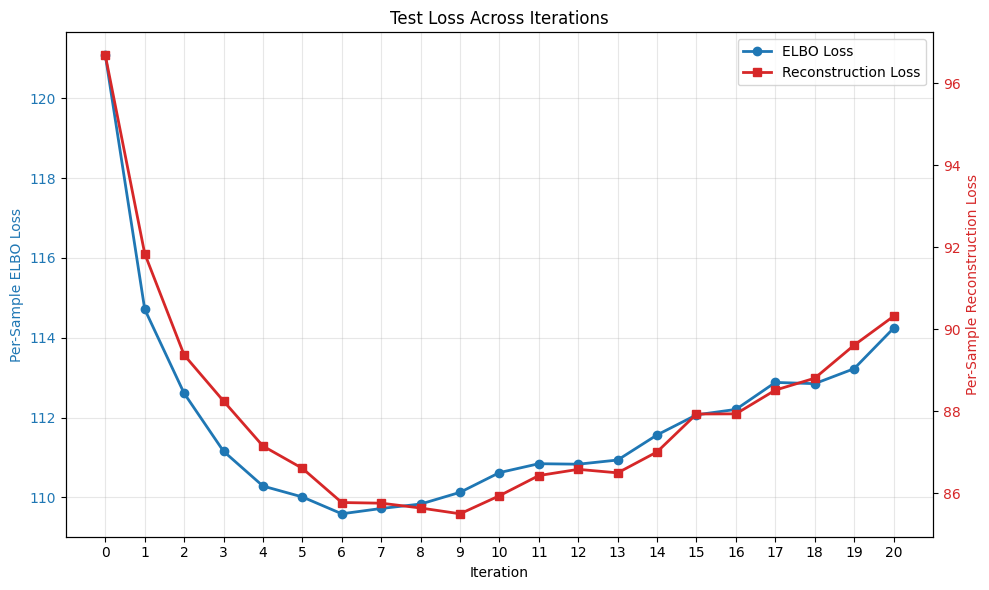

In [41]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot val_loss (ELBO) on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Per-Sample ELBO Loss', color=color1)
line1 = ax1.plot(range(len(res_table_delta50K['val_loss'])), res_table_delta50K['val_loss'], 
                 color=color1, marker='o', linewidth=2, markersize=6, label='ELBO Loss')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for reconstruction loss
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Per-Sample Reconstruction Loss', color=color2)
line2 = ax2.plot(range(len(res_table_delta50K['val_recon'])), res_table_delta50K['val_recon'], 
                 color=color2, marker='s', linewidth=2, markersize=6, label='Reconstruction Loss')
ax2.tick_params(axis='y', labelcolor=color2)

# Set x-axis ticks
ax1.set_xticks(range(len(res_table_delta50K['val_loss']))) 
ax1.set_xticklabels(range(len(res_table_delta50K['val_loss'])))

# Create combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Add title
plt.title('Test Loss Across Iterations')

plt.savefig('fig_iter_recon_loss.png', dpi=300, bbox_inches='tight')
# Adjust layout and show
plt.tight_layout()
plt.show()


In [39]:
plt.savefig('fig_iter_recon_loss.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Plot and compare loss function

In [40]:
size_schedule_fix = size_schedule
size_schedule = [500,32_000,128_000,256_000,256_000]+[512_000]*11

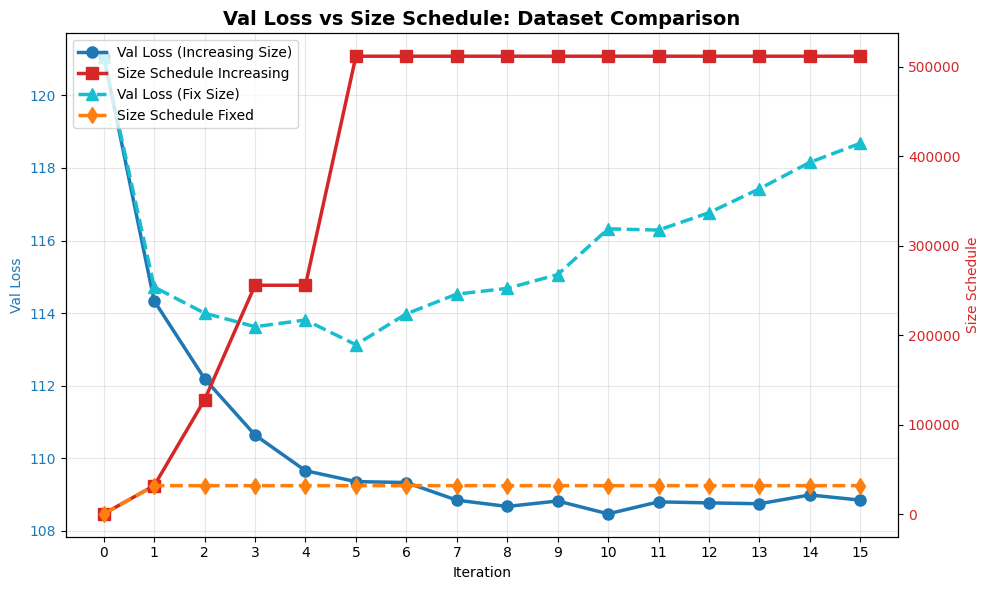

In [43]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Dataset 1 - Primary y-axis (val_loss)
color1 = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Val Loss', color=color1)
line1 = ax1.plot(range(len(res_table['val_loss'])), res_table['val_loss'], 
                 color=color1, marker='o', linewidth=2.5, markersize=8, 
                 label='Val Loss (Increasing Size)', linestyle='-')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Dataset 2 - Primary y-axis (val_loss) - different style
color2 = 'tab:cyan'
line3 = ax1.plot(range(len(res_table_fixsize['val_loss'])), res_table_fixsize['val_loss'], 
                 color=color2, marker='^', linewidth=2.5, markersize=8, 
                 label='Val Loss (Fix Size)', linestyle='--')

# Create secondary y-axis for size_schedule
ax2 = ax1.twinx()

# Dataset 1 - Secondary y-axis (size_schedule)
color3 = 'tab:red'
ax2.set_ylabel('Size Schedule', color=color3)
line2 = ax2.plot(range(len(size_schedule)), size_schedule, 
                 color=color3, marker='s', linewidth=2.5, markersize=8, 
                 label='Size Schedule Increasing', linestyle='-')
ax2.tick_params(axis='y', labelcolor=color3)

# Dataset 2 - Secondary y-axis (size_schedule) - different style
color4 = 'tab:orange'
line4 = ax2.plot(range(len(size_schedule_fix)), size_schedule_fix, 
                 color=color4, marker='d', linewidth=2.5, markersize=8, 
                 label='Size Schedule Fixed', linestyle='--')

# a legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0, 1))

# Set x-axis ticks to show iteration numbers
max_iter = max(len(res_table['val_loss']), len(res_table_fixsize['val_loss']))
ax1.set_xticks(range(max_iter))
ax1.set_xticklabels(range(max_iter))

# Add title
plt.title('Val Loss vs Size Schedule: Dataset Comparison', fontsize=14, fontweight='bold')

# Adjust layout and show
plt.tight_layout()
plt.show()

## Sample quality check

In [27]:
all_models

[CVAE(name=cvae_conv_iclr_real_500, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter1_30000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter2_80000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter3_130000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter4_180000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter5_230000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter6_280000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter7_330000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter8_380000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter9_430000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter10_480000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter11_530000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter12_580000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter13_630000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_iter14_680000, latent_dim=20),
 CVAE(name=cvae_conv_iclr_schedule_

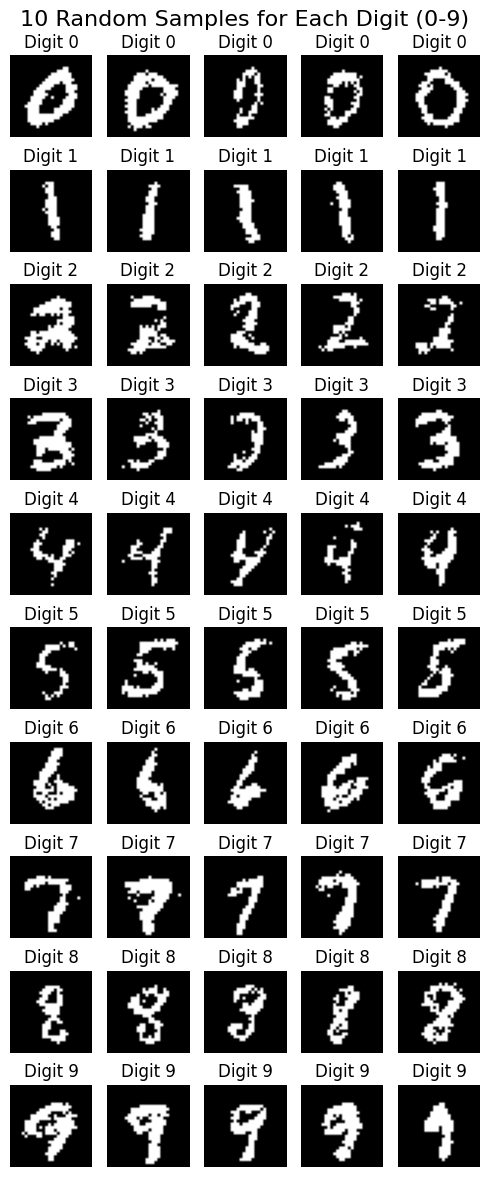

In [34]:
utils.plot_samples_per_digit(5,all_models[-1])

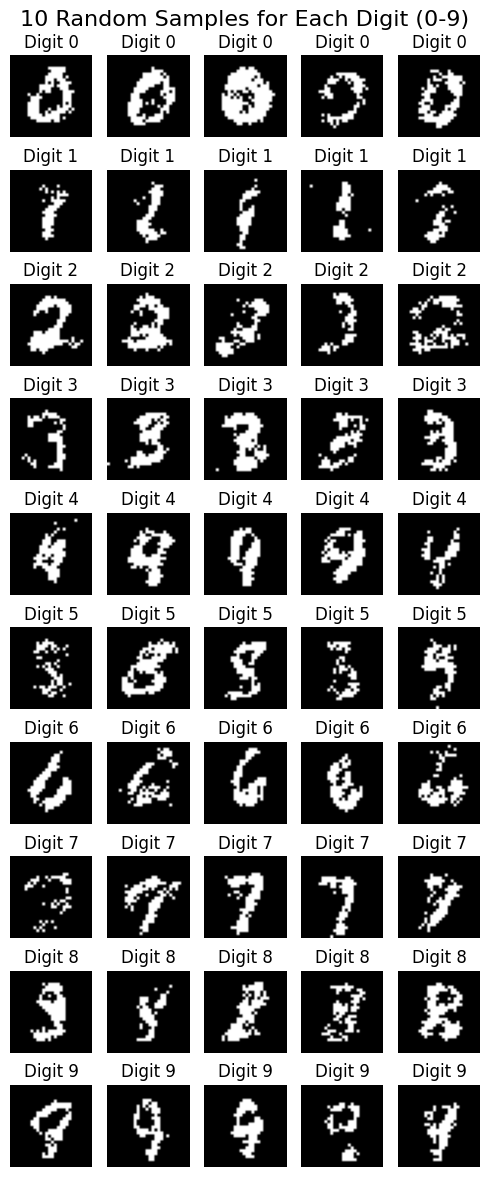

In [33]:
utils.plot_samples_per_digit(5,all_models[6])

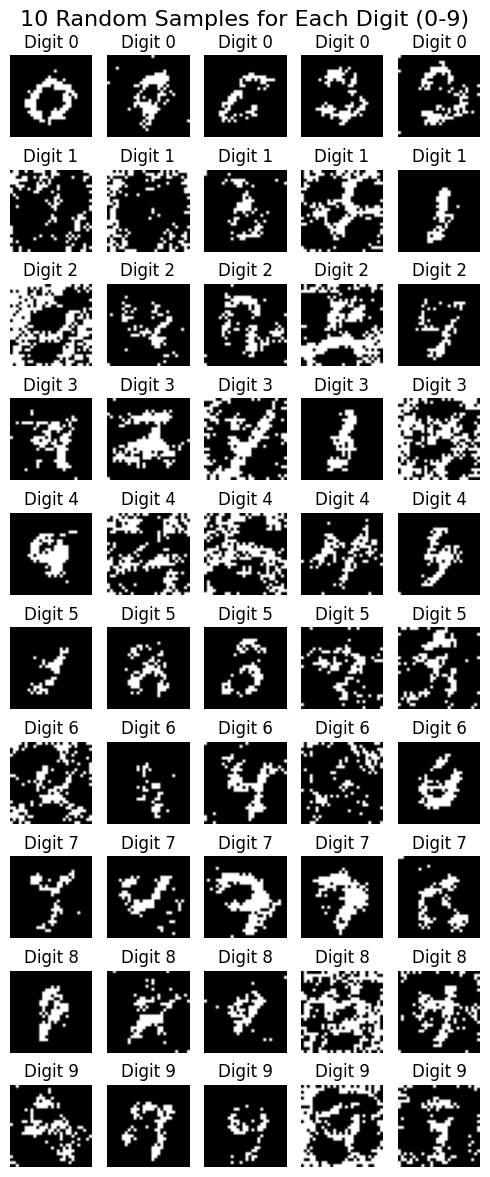

In [29]:
utils.plot_samples_per_digit(5,all_models[0])